# How have player demographics changed over the history of the league?

Here you will find my slightly more unedited and data-forward look at the data for this post. This won't be anything crazy, but perhaps a little more technical, a little more raw data and raw code. My overall design philosophy for this website is to be design and story forward on the front-end, but with more technical detail easily available for the folks who are so inclined. With that, let's look a bit more closely at the raw data.

## Nationality: From pure Canada to North American Mix

In [5]:
# ----------------------------------------------------------------------
#
# LIBRARIES
#
# ----------------------------------------------------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl

# Make sure you're not overwriting later
mpl.rcParams['font.family'] = 'Charter'
print("Using font:", mpl.rcParams['font.family'])  # should say ['Charter']


# Hardcoded project root (adjust if you move the repo)
PROJECT_ROOT = "/Users/dwiwad/dev/hockey_site"

Using font: ['Charter']


In [6]:
# ----------------------------------------------------------------------
#
# READ IN THE DATA
#
# ----------------------------------------------------------------------

roster = pd.read_csv("~/dev/hockey_site/data/nhl-player-demographics/rosters.csv")

# ----------------------------------------------------------------------
#
# ROSTER COUNTS
#
# ----------------------------------------------------------------------

print('Total number of NHL rostered players from 1917 to 2025:', len(roster))
print('Total roster years:', roster['season'].nunique())
print('Total unique rostered players from 1917 to 2025:', roster['id'].nunique())

Total number of NHL rostered players from 1917 to 2025: 55567
Total roster years: 107
Total unique rostered players from 1917 to 2025: 8595


In [7]:
# ----------------------------------------------------------------------
#
# NATIONALITY PROPORTIONS IN THE 2024-2025 AND OVERALL PLOT
#
# ----------------------------------------------------------------------

# Get the simple counts of country by season
country_year_df = roster.groupby(['season', 'birth_country']).size().reset_index(name='count')

# Add in total players per season
country_year_df['total_players'] = country_year_df.groupby('season')['count'].transform('sum')

# Add in proportions
country_year_df['country_prop'] = (country_year_df['count'] / country_year_df['total_players'])

# Split season into a nice labelled variable
def split_and_hyphenate(number):
    s_number = str(number)
    # Example: Split into first 3 and remaining digits
    part1 = s_number[:4]
    part2 = s_number[4:]
    return f"{part1}-{part2}"

# Apply the function to create a new column
country_year_df['season_label'] = country_year_df['season'].apply(split_and_hyphenate)

# Clean up the countries into groupings
def map_country_group(country):
    if country == 'CAN':
        return 'Canada'
    elif country == 'USA':
        return 'USA'
    elif country in ['SWE', 'FIN', 'NOR', 'DNK']:
        return 'Scandinavia'
    elif country in ['CZE', 'SVK']:
        return 'Central Europe'
    elif country in ['RUS', 'BLR', 'UKR', 'KAZ']:
        return 'Former USSR'
    elif country in ['DEU', 'AUT', 'SUI']:  # Germany, Austria, Switzerland
        return 'Western Europe'
    elif country in ['FRA', 'GBR', 'IRL', 'NLD', 'BEL']:
        return 'Other Europe'
    else:
        return 'Other'

# Apply dataframe dataframe
country_year_df['country_group'] = country_year_df['birth_country'].apply(map_country_group)

# ----------------------------------------------------------------------
# AGGREGATION FOR PLOTTING
# ----------------------------------------------------------------------

# Get the max season
latest_season = country_year_df['season'].max()

# Get the latest group totals
latest_group_totals = (
    country_year_df.query("season == @latest_season")
    .groupby('country_group', as_index=False)['country_prop']
    .sum()
)

latest_order = (
    latest_group_totals
    .sort_values('country_prop', ascending=False)['country_group']
    .tolist()
)

top_groups = latest_group_totals.nlargest(5, 'country_prop')['country_group'].tolist()

# aggregate to group-by-season before plotting 
plot_df = (
    country_year_df[country_year_df['country_group'].isin(top_groups)]
    .groupby(['season', 'country_group'], as_index=False)['country_prop']
    .sum()
)

# Re-add the season label
plot_df['season_label'] = plot_df['season'].apply(split_and_hyphenate)

# Convert to categorical to enforce order
plot_df['country_group'] = pd.Categorical(plot_df['country_group'], categories=top_groups, ordered=True)


### Plot the country trends

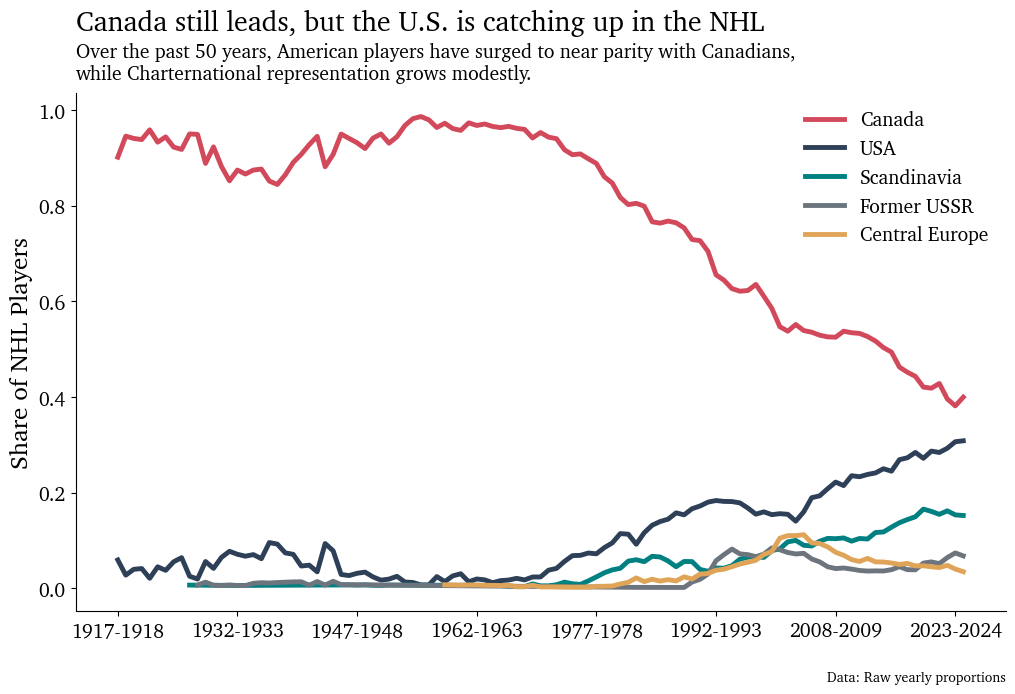

In [8]:
# ----------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=plot_df,
    x="season_label",
    y="country_prop",
    hue="country_group",
    palette={
        'Canada': '#D1495B',
        'USA': '#2E4057',
        'Scandinavia': '#008080',
        'Central Europe': '#E0A458',
        'Former USSR': '#6C757D'
    },
    linewidth=3.5,
    ax=ax,
    errorbar=None  
)

# Set a clean aesthetic style
mpl.rcParams['font.family'] = 'Charter'
sns.despine()
ax.grid(False)

# X-tick labels
# Get unique season labels every 15 steps
tick_labels = plot_df['season_label'].unique()[::15]

# Set ticks and labels using actual string values
ax.set_xticks(tick_labels)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Share of NHL Players", fontsize=18)

# Calculate left margin in figure coords
left_x = ax.get_position().x0

# Reserve more space at the top for the titles
plt.subplots_adjust(top=0.85)  # moves the plot down, freeing top 15% of figure height

# Title (main)
fig.suptitle(
    "Canada still leads, but the U.S. is catching up in the NHL",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=.97  # Top of reserved space
)

# Subtitle
fig.text(
    left_x,
    0.87,  # Slightly below the main title
    "Over the past 50 years, American players have surged to near parity with Canadians,\n"
    "while Charternational representation grows modestly.",
    fontsize=14,
    ha='left'
)

fig.text(
    0.9,
    0.01,
    "Data: Raw yearly proportions", 
    fontsize=10, 
    style='italic', 
    ha='right'
)

# Legend
ax.legend(title="", frameon=False, loc='upper right', fontsize=14)

plt.show()

## Deep Dive Final Age, Height, and Weight Figures

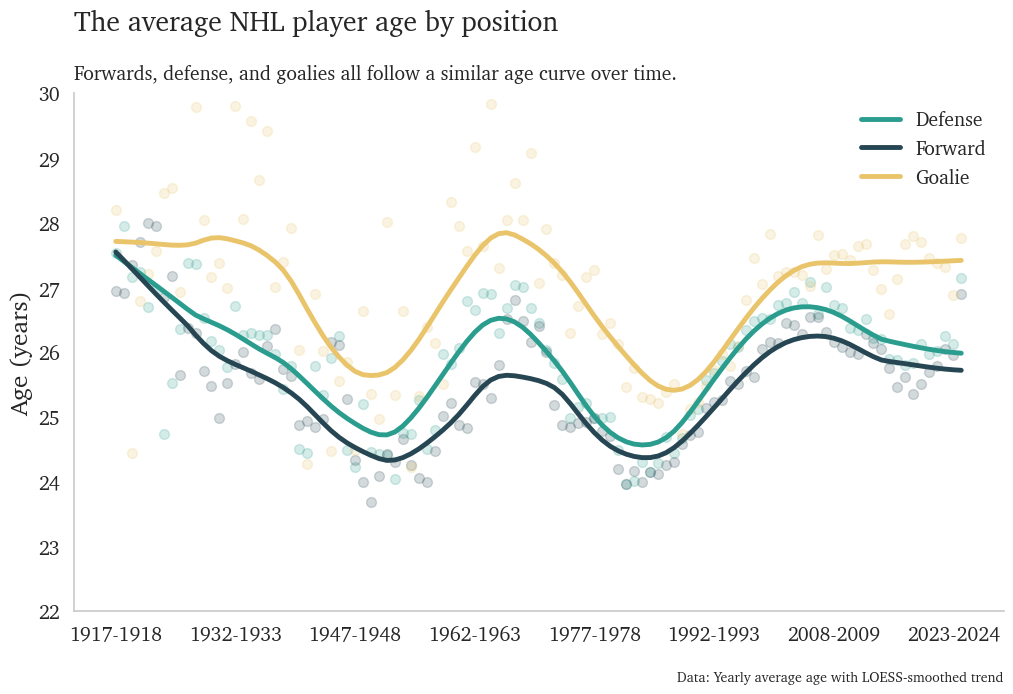

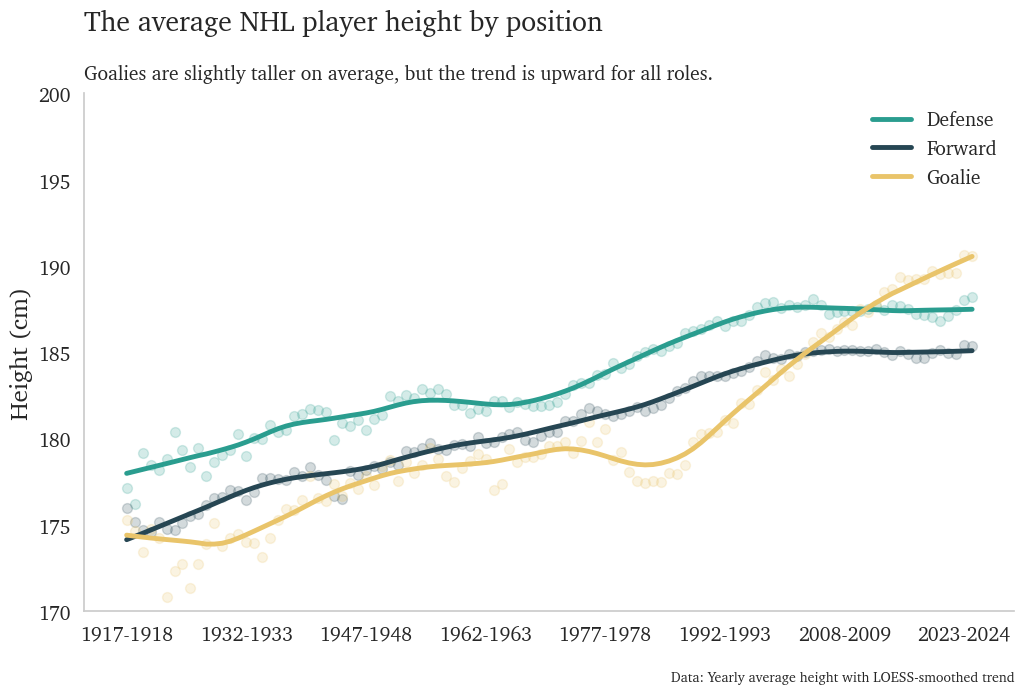

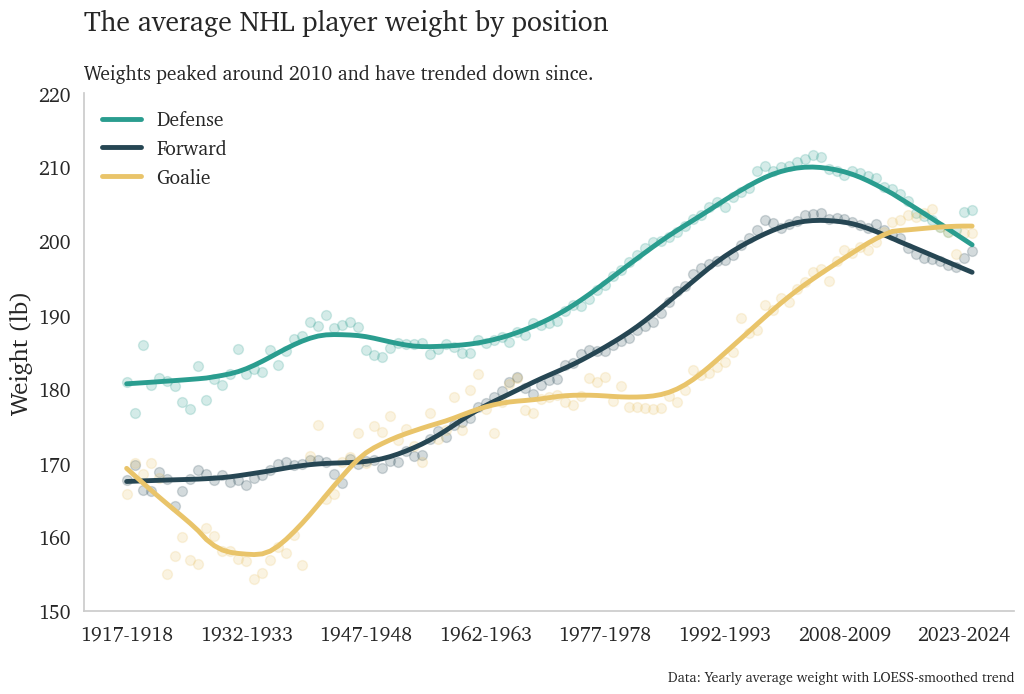

In [9]:
# ----------------------------------------------------------------------
#
# CLEAN AGE, HEIGHT, AND WEIGHT BY POSITION GROUP
#
# ----------------------------------------------------------------------

# Get roster size by year 
season_roster_size = roster.groupby('season')['id'].nunique()

# Map position to groups
position_map = {'C': 'Forward', 'R': 'Forward', 'L': 'Forward', 'D': 'Defense', 'G': 'Goalie'}
roster['position_group'] = roster['position'].map(position_map)

# Convert height to cm
roster['height_cm'] = roster['height_in'] * 2.54

# Format season label
def split_and_hyphenate(number):
    s_number = str(number)
    return f"{s_number[:4]}-{s_number[4:]}"


# Plotting function
def plot_clean_position_trend(df, value_col, ylabel, title, subtitle, filename, ylims, yticks, color_map):
    sns.set(style="whitegrid")
    mpl.rcParams['font.family'] = 'Charter'
    fig, ax = plt.subplots(figsize=(12, 7))

    for group in df['position_group'].unique():
        group_df = df[df['position_group'] == group]

        # Dots
        ax.scatter(
            group_df['x_pos'],
            group_df[value_col],
            color=color_map[group],
            alpha=0.2,
            s=50
        )

        # Smoothed LOESS line
        smoothed = lowess(
            endog=group_df[value_col],
            exog=group_df['x_pos'],
            frac=0.2,
            return_sorted=True
        )
        ax.plot(
            smoothed[:, 0],
            smoothed[:, 1],
            color=color_map[group],
            linewidth=3.5,
            label=group
        )

    ax.set_ylim(ylims)
    ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
    sns.despine()
    ax.grid(False)

    tick_indices = list(range(0, len(season_labels), 15))
    tick_labels = [season_labels[i] for i in tick_indices]
    ax.set_xticks(tick_indices)
    ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_xlabel("")

    left_x = ax.get_position().x0
    plt.subplots_adjust(top=0.85)
    fig.suptitle(title, fontsize=20, weight='bold', x=left_x, ha='left', y=0.97)
    fig.text(left_x, 0.87, subtitle, fontsize=14, ha='left')
    clean_label = {"age": "age", "height_cm": "height", "weight_lb": "weight"}.get(value_col, value_col.split("_")[0])
    fig.text(0.9, 0.01, f"Data: Yearly average {clean_label} with LOESS-smoothed trend", 
             fontsize=10, style='italic', ha='right')
    legend_loc = 'upper left' if value_col == 'weight_lb' else 'upper right'
    ax.legend(title='', loc=legend_loc, frameon = False, fontsize = 14)
    plt.show()

# Loop for each variable
for varname, ylabel, title, subtitle, filename, ylims, yticks in [
    (
        'age',
        'Age (years)',
        'The average NHL player age by position',
        'Forwards, defense, and goalies all follow a similar age curve over time.',
        'nhl_age_by_position.png',
        (22, 30),
        range(22, 31)
    ),
    (
        'height_cm',
        'Height (cm)',
        'The average NHL player height by position',
        'Goalies are slightly taller on average, but the trend is upward for all roles.',
        'nhl_height_by_position.png',
        (170, 200),
        range(170, 201, 5)
    ),
    (
        'weight_lb',
        'Weight (lb)',
        'The average NHL player weight by position',
        'Weights peaked around 2010 and have trended down since.',
        'nhl_weight_by_position.png',
        (150, 220),                # <-- y-axis limits
        range(150, 221, 10)        # <-- y-axis ticks
    )
]:
    temp_df = roster.dropna(subset=['season', 'birth_date', 'position_group']).copy()
    temp_df['birth_date'] = pd.to_datetime(temp_df['birth_date'])
    temp_df['reference_date'] = pd.to_datetime(temp_df['season'].astype(str).str[:4] + '-01-01')

    if varname == 'age':
        temp_df['value'] = (temp_df['reference_date'] - temp_df['birth_date']).dt.days / 365.25
    else:
        temp_df['value'] = temp_df[varname]

    temp_df['season_label'] = temp_df['season'].apply(split_and_hyphenate)

    avg_df = (
        temp_df.groupby(['season_label', 'position_group'])['value']
        .mean()
        .reset_index()
        .rename(columns={'value': varname})
    )

    season_labels = avg_df['season_label'].unique()
    season_to_index = {label: i for i, label in enumerate(season_labels)}
    avg_df['x_pos'] = avg_df['season_label'].map(season_to_index)

    color_map = {
        'Forward': '#264653',
        'Defense': '#2a9d8f',
        'Goalie': '#e9c46a'
    }

    plot_clean_position_trend(
        df=avg_df,
        value_col=varname,
        ylabel=ylabel,
        title=title,
        subtitle=subtitle,
        filename=filename,
        ylims=ylims,
        yticks=yticks,
        color_map=color_map
    )


## More Raw Data

Okay, I just want to include some slightly more raw data into this markdown doc. First, I just want to visualize age, height, and weight raw.

/var/folders/6h/tx376b3j50b3l_gd8kwlgxqh0000gn/T/ipykernel_2156/2422083265.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().remove()


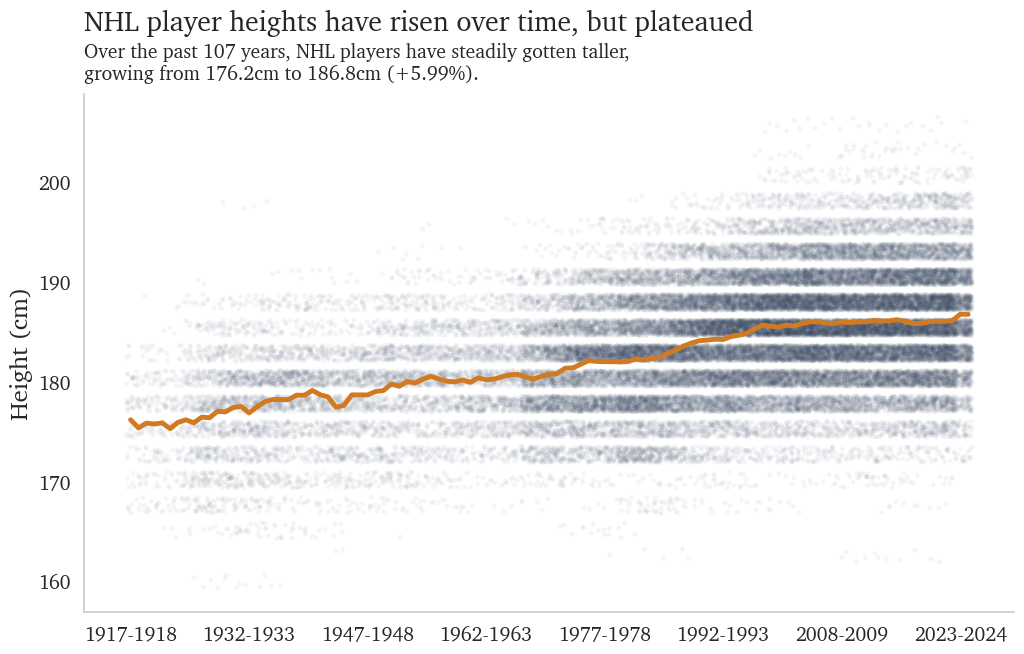

In [11]:
# Clean up data and convert height to cm
height_df = roster[['season', 'height_in']].dropna().copy()
height_df['height_cm'] = height_df['height_in'] * 2.54
height_df['season_label'] = height_df['season'].apply(split_and_hyphenate)

# Create jittered data
np.random.seed(42)
jittered_x = np.arange(len(height_df)) + np.random.uniform(-0.5, 0.5, size=len(height_df))
jittered_y = height_df['height_cm'] + np.random.uniform(-0.8, 0.8, size=len(height_df))

# Map seasons to numeric x values
season_labels = height_df['season_label'].unique()
season_to_index = {label: i for i, label in enumerate(season_labels)}
height_df['x_pos'] = height_df['season_label'].map(season_to_index)

# Compute average height by season
avg_height = (
    height_df.groupby('season_label')['height_cm']
    .mean()
    .reset_index()
)
avg_height['x_pos'] = avg_height['season_label'].map(season_to_index)

# PLOT
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: faded, jittered dots
ax.scatter(
    height_df['x_pos'] + np.random.uniform(-0.5, 0.5, size=len(height_df)),
    height_df['height_cm'] + np.random.uniform(-0.8, 0.8, size=len(height_df)),
    alpha=0.05,
    color='#3B4B64',
    edgecolor='none',
    s=12
)

# Line: average height per season
sns.lineplot(
    data=avg_height,
    x="x_pos",
    y="height_cm",
    ax=ax,
    color='#D17A22',
    linewidth=3.5,
    zorder=10
)

# Style
sns.despine()
ax.grid(False)

# X-axis ticks and labels
tick_indices = list(range(0, len(season_labels), 15))
tick_labels = [season_labels[i] for i in tick_indices]
ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=0, fontsize=14)

# Y-axis tick label styling
ax.tick_params(axis='y', labelsize=14)

# Axis labels
ax.set_xlabel("")
ax.set_ylabel("Height (cm)", fontsize=18)

# Layout and title position
left_x = ax.get_position().x0
plt.subplots_adjust(top=0.85)

# Title
fig.suptitle(
    "NHL player heights have risen over time, but plateaued",
    fontsize=20,
    weight='bold',
    x=left_x,
    ha='left',
    y=0.97
)

# Subtitle
fig.text(
    left_x,
    0.87,
    "Over the past 107 years, NHL players have steadily gotten taller,\ngrowing from 176.2cm to 186.8cm (+5.99%).",
    fontsize=14,
    ha='left'
)

# No legend needed
ax.legend().remove()

# Save and show
plt.show()